### Topology + Demand Matrix

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

G = nx.DiGraph()

links = [
    ("A", "B", 10, 1),
    ("B", "A", 10, 1),
    ("A", "C", 5, 3),
    ("C", "A", 5, 3),
    ("B", "C", 10, 1),
    ("C", "B", 10, 1),
    ("B", "D", 5, 2),
    ("D", "B", 5, 2),
    ("C", "D", 10, 1),
    ("D", "C", 10, 1),
]

for u, v, cap, w in links:
    G.add_edge(u, v, capacity=cap, weight=w, usage=0)

demands = pd.DataFrame([
    ("A", "D", 4),
    ("A", "C", 2),
    ("B", "D", 3),
    ("C", "B", 1),
], columns=["src", "dst", "demand"])

print("Demand Matrix:")
display(demands)

Demand Matrix:


,src,dst,demand
0,A,D,4
1,A,C,2
2,B,D,3
3,C,B,1


### Routing + Link Usage Computation

In [ ]:
def reset_usage(G):
    for u, v in G.edges():
        G[u][v]["usage"] = 0


def route_demands(G, demands, ecmp=False):
    reset_usage(G)

    for _, row in demands.iterrows():
        s, t, d = row["src"], row["dst"], row["demand"]

        if ecmp:
            paths = list(nx.all_shortest_paths(G, s, t, weight="weight"))
            split = d / len(paths)

            for path in paths:
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    G[u][v]["usage"] += split

        else:
            path = nx.shortest_path(G, s, t, weight="weight")

            for i in range(len(path) - 1):
                u, v = path[i], path[i+1]
                G[u][v]["usage"] += d

### Utilization Computation

In [ ]:
def compute_utilization(G):
    results = []

    for u, v in G.edges():
        usage = G[u][v]["usage"]
        cap = G[u][v]["capacity"]
        util = usage / cap if cap > 0 else 0

        results.append({
            "link": f"{u}->{v}",
            "usage": usage,
            "capacity": cap,
            "utilization": util
        })

    df = pd.DataFrame(results)
    return df.sort_values(by="utilization", ascending=False)

### Visualization

In [ ]:
def draw_graph(G, title="Network"):
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(6,5))
    nx.draw(G, pos, with_labels=True, node_size=2000, node_color='lightblue')

    edge_labels = {}
    for u, v in G.edges():
        usage = G[u][v]["usage"]
        cap = G[u][v]["capacity"]
        edge_labels[(u, v)] = f"{usage:.1f}/{cap}"

    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
    plt.title(title)
    plt.show()

### Execution - Initial Weights

=== Link Utilization ===


,link,usage,capacity,utilization
4,B->D,7,5,1.4
0,A->B,6,10,0.6
3,B->C,2,10,0.2
6,C->B,1,10,0.1
1,A->C,0,5,0.0
2,B->A,0,10,0.0
5,C->A,0,5,0.0
7,C->D,0,10,0.0
8,D->B,0,5,0.0
9,D->C,0,10,0.0


Max Utilization: 1.4


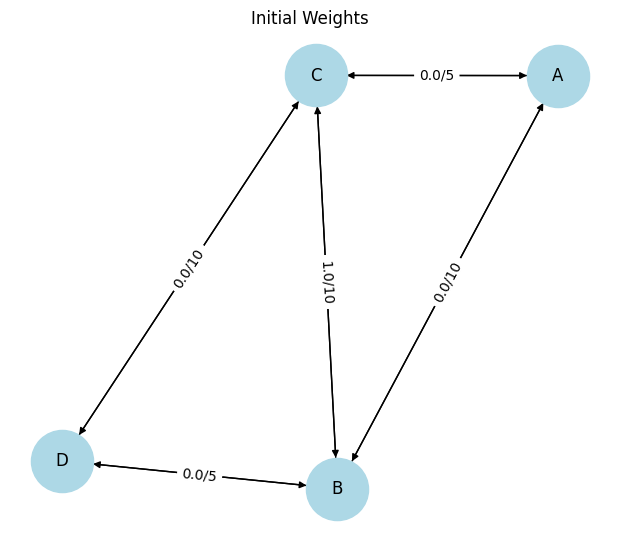

In [ ]:
route_demands(G, demands, ecmp=False)

util_df = compute_utilization(G)
print("=== Link Utilization ===")
display(util_df)

print("Max Utilization:", util_df["utilization"].max())

draw_graph(G, title="Initial Weights")

### Weight Adjustment Experiment

=== After Weight Change ===


,link,usage,capacity,utilization
3,B->C,9,10,0.9
7,C->D,7,10,0.7
0,A->B,6,10,0.6
6,C->B,1,10,0.1
1,A->C,0,5,0.0
2,B->A,0,10,0.0
5,C->A,0,5,0.0
4,B->D,0,5,0.0
8,D->B,0,5,0.0
9,D->C,0,10,0.0


Max Utilization: 0.9


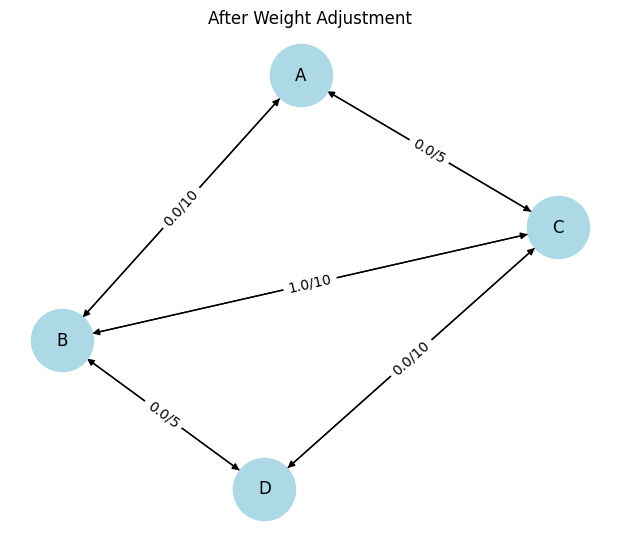

In [ ]:
# Adjust weight to avoid congestion
G["B"]["D"]["weight"] = 5  # from 2 → 5

route_demands(G, demands, ecmp=False)

util_df2 = compute_utilization(G)
print("=== After Weight Change ===")
display(util_df2)

print("Max Utilization:", util_df2["utilization"].max())

draw_graph(G, title="After Weight Adjustment")

### Failure Scenario Analysis

In [ ]:
#Function to make Graph
def build_graph():
  G = nx.DiGraph()
  links = [
    ("A", "B", 10, 1),
    ("B", "A", 10, 1),
    ("A", "C", 5, 3),
    ("C", "A", 5, 3),
    ("B", "C", 10, 1),
    ("C", "B", 10, 1),
    ("B", "D", 5, 2),
    ("D", "B", 5, 2),
    ("C", "D", 10, 1),
    ("D", "C", 10, 1),
  ]
  for u, v, cap, w in links:
    G.add_edge(u, v, capacity=cap, weight=w, usage=0)
  return G

#Single Link Failure
single_results=[]
all_links=list(build_graph().edges())

for failed_link in all_links:
  Gf=build_graph()
  Gf.remove_edge(*failed_link)

  max_util=None
  unreachable=[]

  try:
    route_demands(Gf, demands, ecmp=False)
    util_df_f=compute_utilization(Gf)
    max_util=util_df_f["utilization"].max()
  except nx.NetworkXNoPath as e:
    unreachable.append(str(e))

  single_results.append({
        "failed_link": f"{failed_link[0]}->{failed_link[1]}",
        "max_utilization": round(max_util, 3) if max_util is not None else "N/A",
        "unreachable": "; ".join(unreachable) if unreachable else "None",
    })

single_df=pd.DataFrame(single_results)
print("=== Single Link Failure Results ===")
display(single_df)

=== Single Link Failure Results ===


,failed_link,max_utilization,unreachable
0,A->B,1.2,None
1,A->C,1.4,None
2,B->A,1.4,None
3,B->C,1.4,None
4,B->D,0.9,None
5,C->A,1.4,None
6,C->B,1.4,None
7,C->D,1.4,None
8,D->B,1.4,None
9,D->C,1.4,None


Worst failed link: A->C   (max util = 1.400)


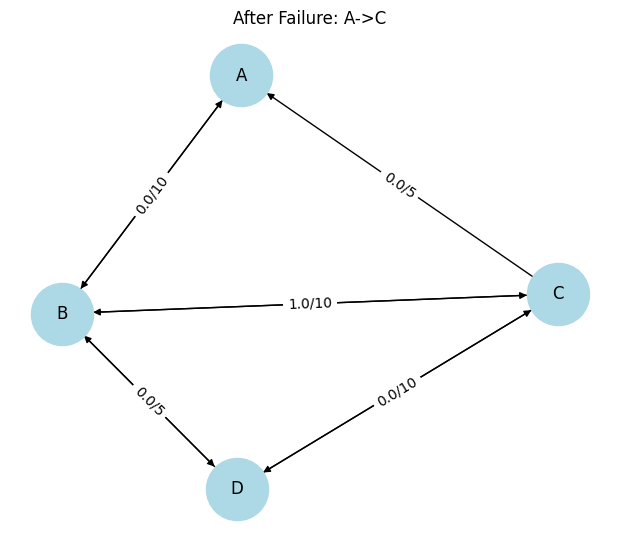

In [ ]:
worst=single_df[single_df["max_utilization"] != "N/A"].copy()
worst["max_utilization"]=worst["max_utilization"].astype(float)
worst_link=worst.loc[worst["max_utilization"].idxmax(), "failed_link"]
u_fail, v_fail=worst_link.split("->")

print(f"Worst failed link: {worst_link}   (max util = {worst['max_utilization'].max():.3f})")

Gworst=build_graph()
Gworst.remove_edge(u_fail, v_fail)
route_demands(Gworst, demands, ecmp=False)
draw_graph(Gworst, title=f"After Failure: {worst_link}")

In [ ]:
from itertools import combinations

double_results=[]

for link_a, link_b in combinations(all_links, 2):
  Gf=build_graph()
  Gf.remove_edge(*link_a)
  if Gf.has_edge(*link_b):
    Gf.remove_edge(*link_b)

  max_util=None
  unreachable=[]

  try:
    route_demands(Gf, demands, ecmp=False)
    util_df_f=compute_utilization(Gf)
    max_util=util_df_f["utilization"].max()
  except nx.NetworkXNoPath as e:
    unreachable.append(str(e))

  double_results.append({
      "failed_links": f"{link_a[0]}->{link_a[1]} + {link_b[0]}->{link_b[1]}",
      "max_utilization": round(max_util, 3) if max_util is not None else "N/A",
      "unreachable": "; ".join(unreachable) if unreachable else "None",
  })

double_df=pd.DataFrame(double_results)
critical=double_df[(double_df["max_utilization"]=="N/A") |
                   (double_df["max_utilization"].apply(
                       lambda x: float(x) > 1.0 if x != "N/A" else False
                   ))]
print(f"Critical scenarios: {len(critical)} / {len(double_df)}")
display(critical.head(20))

Critical scenarios: 39 / 45


,failed_links,max_utilization,unreachable
0,A->B + A->C,N/A,No path between A and D.
1,A->B + B->A,1.2,None
2,A->B + B->C,1.2,None
3,A->B + B->D,1.2,None
4,A->B + C->A,1.2,None
5,A->B + C->B,1.2,None
6,A->B + C->D,1.4,None
7,A->B + D->B,1.2,None
8,A->B + D->C,1.2,None
9,A->C + B->A,1.4,None


In [ ]:
Gbase=build_graph()
route_demands(Gbase, demands)
base_max=compute_utilization(Gbase)["utilization"].max()

reachable_single =single_df[single_df["unreachable"]=="None"]
unreachable_single=single_df[single_df["unreachable"]!="None"]

print("=== Failure Scenario Analysis Summary ===")
print(f"  Baseline max utilization        : {base_max:.3f}")
print(f"  Single-link failures tested     : {len(single_df)}")
print(f"    -> causes unreachable demand  : {len(unreachable_single)}")
if len(reachable_single):
  print(f"   -> worst max utilization       : {reachable_single['max_utilization'].astype(float).max():.3f}")
print(f"  Double-link failures tested     : {len(double_df)}")
print(f"    -> critical scenarios         : {len(critical)}")

=== Failure Scenario Analysis Summary ===
  Baseline max utilization        : 1.400
  Single-link failures tested     : 10
    -> causes unreachable demand  : 0
   -> worst max utilization       : 1.400
  Double-link failures tested     : 45
    -> critical scenarios         : 39
